In [4]:
import os
print(os.listdir())

['.config', 'Lab Session Data.xlsx', 'sample_data']


In [33]:
import pandas as pd
import numpy as np

def load_data(file_path):
    data = pd.read_excel(file_path, sheet_name="Purchase data")
    X = data[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]].to_numpy()
    y = data["Payment (Rs)"].to_numpy().reshape(-1, 1)
    return X, y

def get_rank(X):
    return np.linalg.matrix_rank(X)

def get_product_costs(X, y):
    return np.linalg.pinv(X) @ y

def main():
    X, y = load_data("Lab Session Data.xlsx")
    print("Feature Matrix (X):")
    print(X)
    print("\nOutput Vector (y):")
    print(y)
    print("\nDimensionality:", X.shape[1])
    print("\nNumber of Vectors:", X.shape[0])
    print("\nRank of Feature Matrix:", get_rank(X))
    costs = get_product_costs(X, y)
    print("\nEstimated Cost of Products")
    print(f"Candy : Rs. {costs[0][0]:.2f}")
    print(f"Mango : Rs. {costs[1][0]:.2f}")
    print(f"Milk  : Rs. {costs[2][0]:.2f}")

if __name__ == "__main__":
    main()

Feature Matrix (X):
[[20  6  2]
 [16  3  6]
 [27  6  2]
 [19  1  2]
 [24  4  2]
 [22  1  5]
 [15  4  2]
 [18  4  2]
 [21  1  4]
 [16  2  4]]

Output Vector (y):
[[386]
 [289]
 [393]
 [110]
 [280]
 [167]
 [271]
 [274]
 [148]
 [198]]

Dimensionality: 3

Number of Vectors: 10

Rank of Feature Matrix: 3

Estimated Cost of Products
Candy : Rs. 1.00
Mango : Rs. 55.00
Milk  : Rs. 18.00


In [34]:
import pandas as pd

def load_data(file_path):
    data = pd.read_excel(file_path, sheet_name="Purchase data")
    data["Class"] = data["Payment (Rs)"].apply(lambda x: "RICH" if x > 200 else "POOR")
    return data

def main():
    data = load_data("Lab Session Data.xlsx")
    print(data[["Customer", "Payment (Rs)", "Class"]])

if __name__ == "__main__":
    main()

  Customer  Payment (Rs) Class
0      C_1           386  RICH
1      C_2           289  RICH
2      C_3           393  RICH
3      C_4           110  POOR
4      C_5           280  RICH
5      C_6           167  POOR
6      C_7           271  RICH
7      C_8           274  RICH
8      C_9           148  POOR
9     C_10           198  POOR


Custom Mean: 1560.6634538152598
NumPy Mean: 1560.6634538152612

Custom Variance: 58496.49239931618
NumPy Variance: 58496.49239931613

Average Time (Custom Mean): 3.136250002171437e-05
Average Time (NumPy Mean): 8.815199998934986e-06

Average Time (Custom Variance): 0.00011470609997559223
Average Time (NumPy Variance): 2.7882299991688343e-05

Wednesday Mean: 1550.7060000000001
Population Mean: 1560.6634538152612

April Mean: 1698.9526315789474
Population Mean: 1560.6634538152612

Probability of Loss: 0.4979919678714859
Probability of Profit on Wednesday: 0.08433734939759036
Conditional Probability of Profit given Wednesday: 0.42


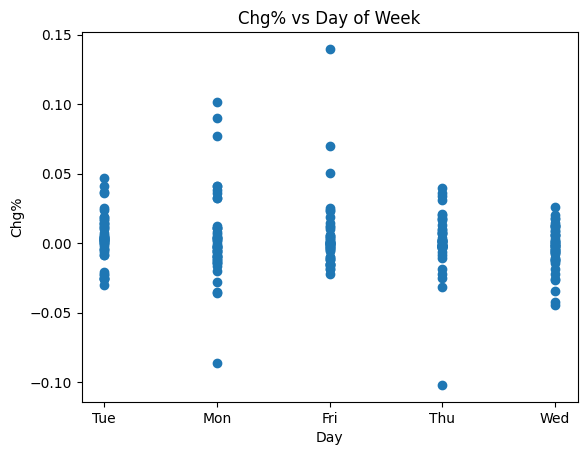

In [35]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

def load_data(file_path):
    return pd.read_excel(file_path, sheet_name="IRCTC Stock Price")

def calculate_mean(price):
    return sum(price) / len(price)

def calculate_variance(price):
    mean = calculate_mean(price)
    return sum((x - mean) ** 2 for x in price) / len(price)

def average_time(function, data):
    total_time = 0
    for _ in range(10):
        start = time.perf_counter()
        function(data)
        end = time.perf_counter()
        total_time += (end - start)
    return total_time / 10

def main():

    data = load_data("Lab Session Data.xlsx")

    price = data["Price"].dropna().to_numpy()

    custom_mean = calculate_mean(price)
    custom_variance = calculate_variance(price)

    numpy_mean = np.mean(price)
    numpy_variance = np.var(price)

    print("Custom Mean:", custom_mean)
    print("NumPy Mean:", numpy_mean)

    print("\nCustom Variance:", custom_variance)
    print("NumPy Variance:", numpy_variance)

    print("\nAverage Time (Custom Mean):", average_time(calculate_mean, price))
    print("Average Time (NumPy Mean):", average_time(np.mean, price))

    print("\nAverage Time (Custom Variance):", average_time(calculate_variance, price))
    print("Average Time (NumPy Variance):", average_time(np.var, price))

    wednesday_mean = np.mean(data[data["Day"] == "Wed"]["Price"])
    april_mean = np.mean(data[data["Month"] == "Apr"]["Price"])

    print("\nWednesday Mean:", wednesday_mean)
    print("Population Mean:", numpy_mean)

    print("\nApril Mean:", april_mean)
    print("Population Mean:", numpy_mean)

    loss_probability = len(data[data["Chg%"] < 0]) / len(data)

    wednesday_data = data[data["Day"] == "Wed"]

    profit_wednesday = len(wednesday_data[wednesday_data["Chg%"] > 0]) / len(data)

    conditional_probability = (
        len(wednesday_data[wednesday_data["Chg%"] > 0]) / len(wednesday_data)
    )

    print("\nProbability of Loss:", loss_probability)
    print("Probability of Profit on Wednesday:", profit_wednesday)
    print("Conditional Probability of Profit given Wednesday:", conditional_probability)

    plt.scatter(data["Day"], data["Chg%"])
    plt.xlabel("Day")
    plt.ylabel("Chg%")
    plt.title("Chg% vs Day of Week")
    plt.show()

if __name__ == "__main__":
    main()

In [36]:
import pandas as pd
import numpy as np

def load_data(file_path):
    return pd.read_excel(file_path, sheet_name="thyroid0387_UCI", na_values="?")

def attribute_types(data):
    result = []
    for column in data.columns:
        if data[column].dtype == "object":
            encoding = "Label Encoding" if data[column].nunique() == 2 else "One-Hot Encoding"
            result.append([column, "Categorical", encoding])
        else:
            result.append([column, "Numeric", "Not Required"])
    return pd.DataFrame(result, columns=["Attribute", "Type", "Encoding"])

def numeric_summary(data):
    return data.describe().loc[["min", "max", "mean", "std"]]

def missing_values(data):
    return data.isnull().sum()

def outliers(data):
    numeric = data.select_dtypes(include=np.number)
    result = {}
    for column in numeric.columns:
        q1 = numeric[column].quantile(0.25)
        q3 = numeric[column].quantile(0.75)
        iqr = q3 - q1
        count = ((numeric[column] < (q1 - 1.5 * iqr)) |
                 (numeric[column] > (q3 + 1.5 * iqr))).sum()
        result[column] = count
    return result

def main():
    data = load_data("Lab Session Data.xlsx")

    print("Attribute Types and Encoding")
    print(attribute_types(data))

    print("\nNumeric Data Range, Mean and Standard Deviation")
    print(numeric_summary(data))

    print("\nVariance")
    print(data.select_dtypes(include=np.number).var())

    print("\nMissing Values")
    print(missing_values(data))

    print("\nOutliers")
    for column, count in outliers(data).items():
        print(column, ":", count)

if __name__ == "__main__":
    main()

Attribute Types and Encoding
                    Attribute         Type          Encoding
0                   Record ID      Numeric      Not Required
1                         age      Numeric      Not Required
2                         sex  Categorical    Label Encoding
3                on thyroxine  Categorical    Label Encoding
4          query on thyroxine  Categorical    Label Encoding
5   on antithyroid medication  Categorical    Label Encoding
6                        sick  Categorical    Label Encoding
7                    pregnant  Categorical    Label Encoding
8             thyroid surgery  Categorical    Label Encoding
9              I131 treatment  Categorical    Label Encoding
10          query hypothyroid  Categorical    Label Encoding
11         query hyperthyroid  Categorical    Label Encoding
12                    lithium  Categorical    Label Encoding
13                     goitre  Categorical    Label Encoding
14                      tumor  Categorical    Label Enco

In [37]:
import pandas as pd

def load_data(file_path):
    return pd.read_excel("Lab Session Data.xlsx", sheet_name="thyroid0387_UCI")

def binary_columns(data):
    columns = []
    for column in data.columns:
        values = set(data[column].astype(str).str.lower().unique())
        if values.issubset({"t", "f"}):
            columns.append(column)
    return columns

def calculate_similarity(vector1, vector2):

    f11 = f10 = f01 = f00 = 0

    for a, b in zip(vector1, vector2):

        if a == "t" and b == "t":
            f11 += 1
        elif a == "t" and b == "f":
            f10 += 1
        elif a == "f" and b == "t":
            f01 += 1
        else:
            f00 += 1

    jaccard = f11 / (f11 + f10 + f01)

    smc = (f11 + f00) / (f11 + f10 + f01 + f00)

    return jaccard, smc

def main():
    data = load_data("Lab Session Data.xlsx")

    columns = binary_columns(data)

    vector1 = data.loc[0, columns].astype(str).str.lower()

    vector2 = data.loc[1, columns].astype(str).str.lower()

    jaccard, smc = calculate_similarity(vector1, vector2)

    print("Binary Attributes")
    print(columns)

    print("\nJaccard Coefficient:", jaccard)

    print("Simple Matching Coefficient:", smc)

if __name__ == "__main__":
    main()

Binary Attributes
['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured']

Jaccard Coefficient: 0.25
Simple Matching Coefficient: 0.85


In [38]:
import pandas as pd
import numpy as np

def load_data(file_path):
    return pd.read_excel(file_path, sheet_name="thyroid0387_UCI", na_values="?")

def preprocess_data(data):

    data = data.drop(columns=["Record ID"])

    for column in data.columns:

        if data[column].dtype == "object":
            data[column] = data[column].fillna(data[column].mode()[0])
        else:
            data[column] = data[column].fillna(data[column].median())

    data = pd.get_dummies(data)

    return data

def cosine_similarity(vector1, vector2):

    dot_product = np.dot(vector1, vector2)

    magnitude1 = np.linalg.norm(vector1)

    magnitude2 = np.linalg.norm(vector2)

    return dot_product / (magnitude1 * magnitude2)

def main():

    data = load_data("Lab Session Data.xlsx")

    processed_data = preprocess_data(data)

    vector1 = processed_data.iloc[0].to_numpy(dtype=float)

    vector2 = processed_data.iloc[1].to_numpy(dtype=float)

    similarity = cosine_similarity(vector1, vector2)

    print("Cosine Similarity:", similarity)

if __name__ == "__main__":
    main()

Cosine Similarity: 0.9944966384452464


/tmp/ipykernel_950/1707968450.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary = first20.applymap(lambda x: 1 if x else 0).to_numpy()


Jaccard Matrix
[[1.         0.73333333 0.66666667 0.72413793 0.66666667 0.72413793
  0.72413793 0.67741935 0.73333333 0.73333333 0.73333333 0.73333333
  0.78571429 0.73333333 0.66666667 0.85185185 0.67741935 0.59375
  0.51428571 0.58823529]
 [0.73333333 1.         0.57575758 0.625      0.57575758 0.625
  0.625      0.92857143 1.         1.         1.         1.
  0.67741935 1.         0.73333333 0.73333333 0.92857143 0.82758621
  0.57142857 0.6969697 ]
 [0.66666667 0.57575758 1.         0.92307692 0.85185185 0.92307692
  0.92307692 0.52941176 0.57575758 0.57575758 0.57575758 0.57575758
  0.61290323 0.57575758 0.66666667 0.66666667 0.52941176 0.59375
  0.39473684 0.45945946]
 [0.72413793 0.625      0.92307692 1.         0.92307692 1.
  1.         0.57575758 0.625      0.625      0.625      0.625
  0.66666667 0.625      0.72413793 0.72413793 0.57575758 0.64516129
  0.43243243 0.42105263]
 [0.66666667 0.57575758 0.85185185 0.92307692 1.         0.92307692
  0.92307692 0.52941176 0.5757575

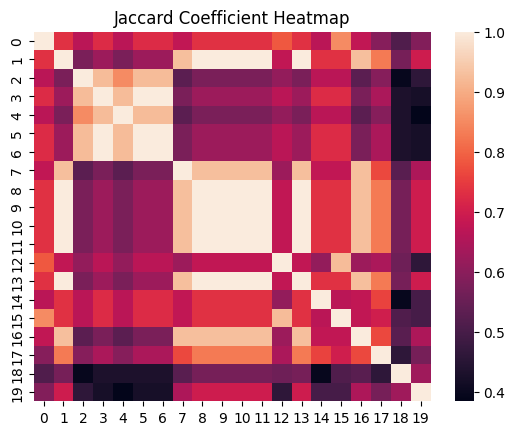

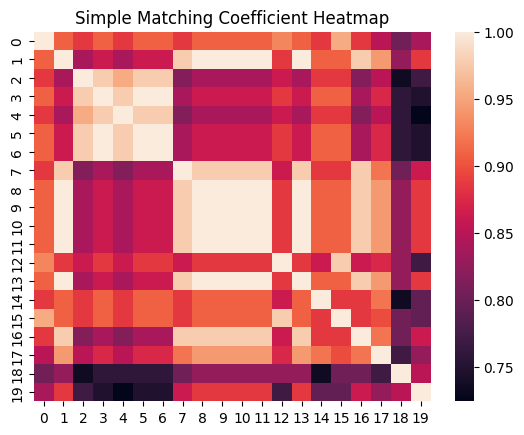

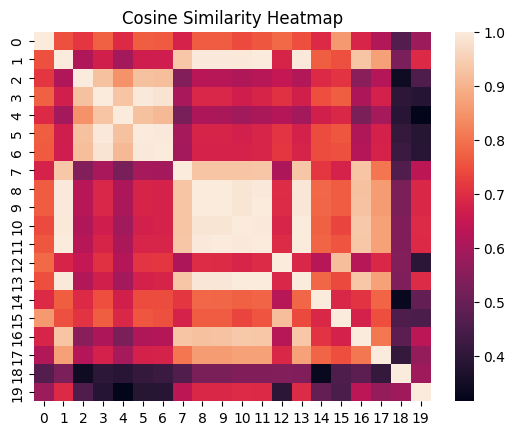

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def load_data(file_path):
    return pd.read_excel(file_path, sheet_name="thyroid0387_UCI", na_values="?")

def jaccard(v1, v2):
    f11 = f10 = f01 = 0

    for a, b in zip(v1, v2):
        if a == 1 and b == 1:
            f11 += 1
        elif a == 1 and b == 0:
            f10 += 1
        elif a == 0 and b == 1:
            f01 += 1

    if (f11 + f10 + f01) == 0:
        return 0

    return f11 / (f11 + f10 + f01)

def smc(v1, v2):
    match = sum(a == b for a, b in zip(v1, v2))
    return match / len(v1)

def cosine(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

def main():

    data = load_data("Lab Session Data.xlsx")

    data = data.drop(columns=["Record ID"])

    encoded_data = pd.get_dummies(data).fillna(0)

    first20 = encoded_data.iloc[:20]

    jc_matrix = np.zeros((20, 20))
    smc_matrix = np.zeros((20, 20))
    cos_matrix = np.zeros((20, 20))

    binary = first20.applymap(lambda x: 1 if x else 0).to_numpy()

    scaler = MinMaxScaler()
    numeric = scaler.fit_transform(first20)

    for i in range(20):
        for j in range(20):
            jc_matrix[i][j] = jaccard(binary[i], binary[j])
            smc_matrix[i][j] = smc(binary[i], binary[j])
            cos_matrix[i][j] = cosine(numeric[i], numeric[j])

    print("Jaccard Matrix")
    print(jc_matrix)

    print("\nSMC Matrix")
    print(smc_matrix)

    print("\nCosine Similarity Matrix")
    print(cos_matrix)

    sns.heatmap(jc_matrix)
    plt.title("Jaccard Coefficient Heatmap")
    plt.show()

    sns.heatmap(smc_matrix)
    plt.title("Simple Matching Coefficient Heatmap")
    plt.show()

    sns.heatmap(cos_matrix)
    plt.title("Cosine Similarity Heatmap")
    plt.show()

if __name__ == "__main__":
    main()

In [40]:
import pandas as pd
import numpy as np

def load_data(file_path):
    return pd.read_excel(file_path, sheet_name="thyroid0387_UCI", na_values="?")

def impute_missing_values(data):

    data = data.copy()

    for column in data.columns:

        if data[column].dtype == "object":

            data[column] = data[column].fillna(data[column].mode()[0])

        else:

            q1 = data[column].quantile(0.25)
            q3 = data[column].quantile(0.75)
            iqr = q3 - q1

            outlier = ((data[column] < (q1 - 1.5 * iqr)) |
                       (data[column] > (q3 + 1.5 * iqr))).any()

            if outlier:
                data[column] = data[column].fillna(data[column].median())
            else:
                data[column] = data[column].fillna(data[column].mean())

    return data

def main():

    data = load_data("Lab Session Data.xlsx")

    imputed_data = impute_missing_values(data)

    print("Missing Values Before")
    print(data.isnull().sum())

    print("\nMissing Values After")
    print(imputed_data.isnull().sum())

if __name__ == "__main__":
    main()

Missing Values Before
Record ID                       0
age                             0
sex                           307
on thyroxine                    0
query on thyroxine              0
on antithyroid medication       0
sick                            0
pregnant                        0
thyroid surgery                 0
I131 treatment                  0
query hypothyroid               0
query hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH measured                    0
TSH                           842
T3 measured                     0
T3                           2604
TT4 measured                    0
TT4                           442
T4U measured                    0
T4U                           809
FTI measured                    0
FTI                           802
TBG measured                    0
TBG                       

In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def load_data(file_path):
    return pd.read_excel(file_path, sheet_name="thyroid0387_UCI", na_values="?")

def impute_missing_values(data):

    data = data.copy()

    for column in data.columns:

        if data[column].dtype == "object":

            data[column] = data[column].fillna(data[column].mode()[0])

        else:

            q1 = data[column].quantile(0.25)
            q3 = data[column].quantile(0.75)
            iqr = q3 - q1

            outlier = ((data[column] < (q1 - 1.5 * iqr)) |
                       (data[column] > (q3 + 1.5 * iqr))).any()

            if outlier:
                data[column] = data[column].fillna(data[column].median())
            else:
                data[column] = data[column].fillna(data[column].mean())

    return data

def main():

    data = load_data("Lab Session Data.xlsx")

    data = impute_missing_values(data)

    numeric_data = data.select_dtypes(include=["number"])

    scaler = MinMaxScaler()

    normalized_data = pd.DataFrame(
        scaler.fit_transform(numeric_data),
        columns=numeric_data.columns
    )

    print("Normalized Data")
    print(normalized_data)

    print("\nMinimum Value:")
    print(normalized_data.min().min())

    print("\nMaximum Value:")
    print(normalized_data.max().max())

if __name__ == "__main__":
    main()

Normalized Data
         Record ID       age       TSH        T3       TT4       T4U  \
0     0.000000e+00  0.000427  0.000557  0.103064  0.170569  0.365741   
1     3.410871e-08  0.000427  0.003009  0.103064  0.210702  0.365741   
2     9.891527e-07  0.000610  0.002632  0.103064  0.170569  0.365741   
3     6.934301e-05  0.000534  0.002632  0.103064  0.170569  0.365741   
4     6.937712e-05  0.000473  0.002632  0.103064  0.170569  0.365741   
...            ...       ...       ...       ...       ...       ...   
9167  9.999996e-01  0.000839  0.002632  0.103064  0.103679  0.305556   
9168  9.999996e-01  0.000320  0.002632  0.103064  0.148829  0.347222   
9169  9.999997e-01  0.001038  0.002632  0.103064  0.185619  0.509259   
9170  9.999997e-01  0.000702  0.002632  0.103064  0.122074  0.314815   
9171  1.000000e+00  0.000458  0.002632  0.103064  0.107023  0.393519   

           FTI       TBG  
0     0.122328  0.129565  
1     0.122328  0.129565  
2     0.122328  0.054527  
3     0.122